
# Applied Statistics (ECS764P) — Lab 2 (CW1a)

This notebook contains fully worked code for:
- **Section 1**: Independent sum of two probability measures
- **Section 2**: Sample mean distribution
- **Section 3**: Maximum Likelihood Estimators
- **Additional Theory Exercises** — detailed solutions


In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, stats

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 120

rng = np.random.default_rng(42)

print("Libraries imported. Ready to go.")


Libraries imported. Ready to go.



## Section 1 — Independent Sum of Two Probability Measures


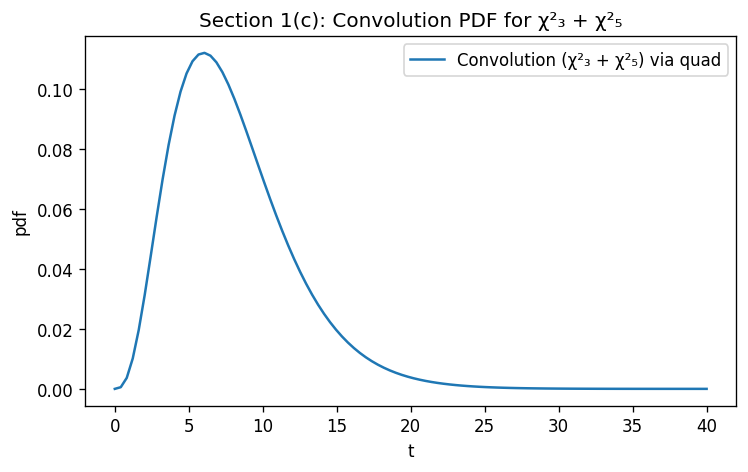

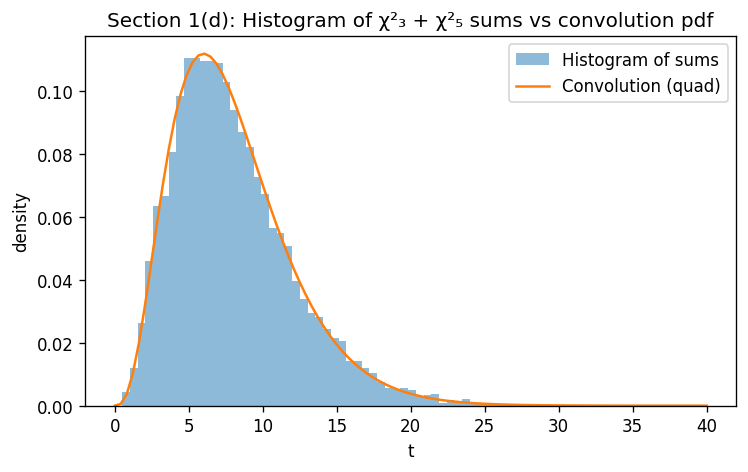

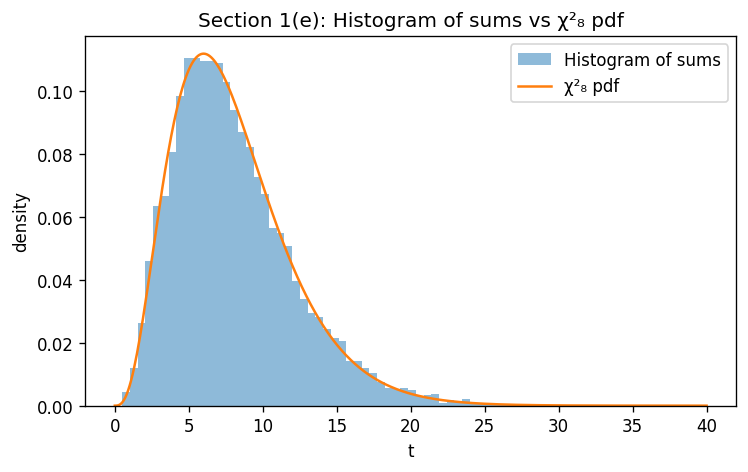

In [16]:

m, n = 3, 5
chi_m = stats.chi2(df=m)
chi_n = stats.chi2(df=n)
chi_mn = stats.chi2(df=m+n)

support_min, support_max = 0.0, 40.0

def integrand(x, t):
    return chi_m.pdf(x) * chi_n.pdf(t - x)

t_grid = np.linspace(support_min, support_max, 100)
conv_pdf = np.zeros_like(t_grid)

for i, t in enumerate(t_grid):
    if t <= 0:
        conv_pdf[i] = 0.0
    else:
        conv_pdf[i] = integrate.quad(lambda x: integrand(x, t), 0, t, limit=200)[0]

plt.plot(t_grid, conv_pdf, label="Convolution (χ²₃ + χ²₅) via quad")
plt.title("Section 1(c): Convolution PDF for χ²₃ + χ²₅")
plt.xlabel("t"); plt.ylabel("pdf"); plt.legend(); plt.show()

samps_m = chi_m.rvs(size=10000, random_state=rng)
samps_n = chi_n.rvs(size=10000, random_state=rng)
samps_sum = samps_m + samps_n

plt.hist(samps_sum, bins=60, density=True, alpha=0.5, label="Histogram of sums")
plt.plot(t_grid, conv_pdf, label="Convolution (quad)")
plt.title("Section 1(d): Histogram of χ²₃ + χ²₅ sums vs convolution pdf")
plt.xlabel("t"); plt.ylabel("density"); plt.legend(); plt.show()

t_grid_dense = np.linspace(0, support_max, 400)
chi_mn_pdf = chi_mn.pdf(t_grid_dense)

plt.hist(samps_sum, bins=60, density=True, alpha=0.5, label="Histogram of sums")
plt.plot(t_grid_dense, chi_mn_pdf, label="χ²₈ pdf")
plt.title("Section 1(e): Histogram of sums vs χ²₈ pdf")
plt.xlabel("t"); plt.ylabel("density"); plt.legend(); plt.show()



## Section 2 — Sample Mean Distributions


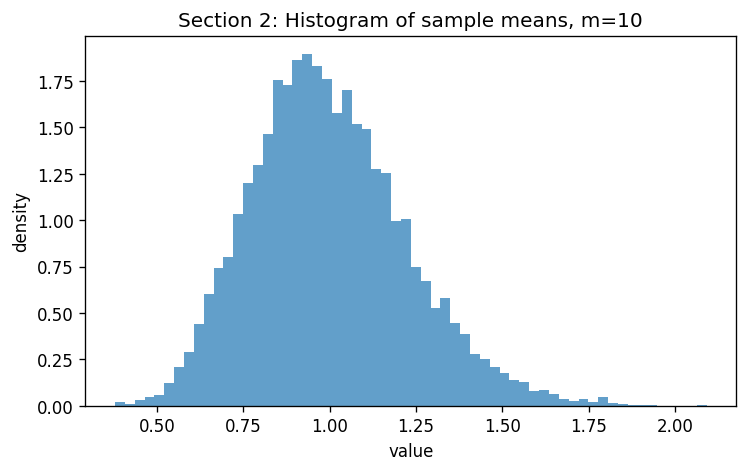

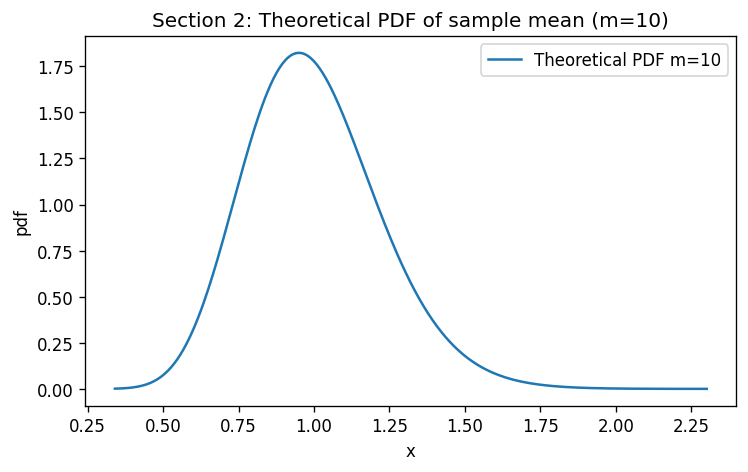

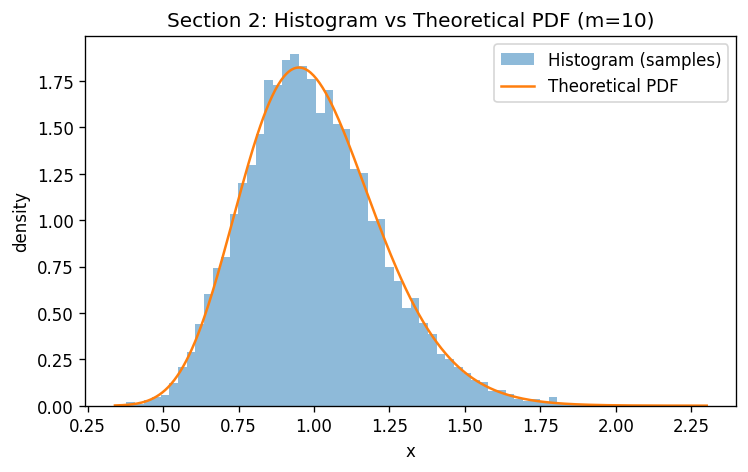

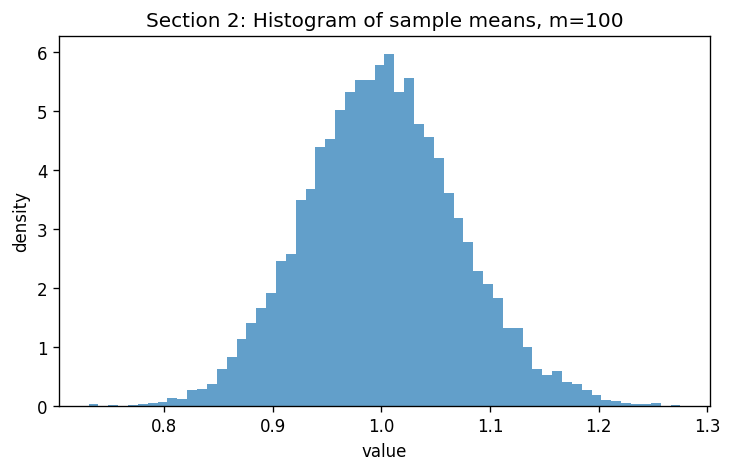

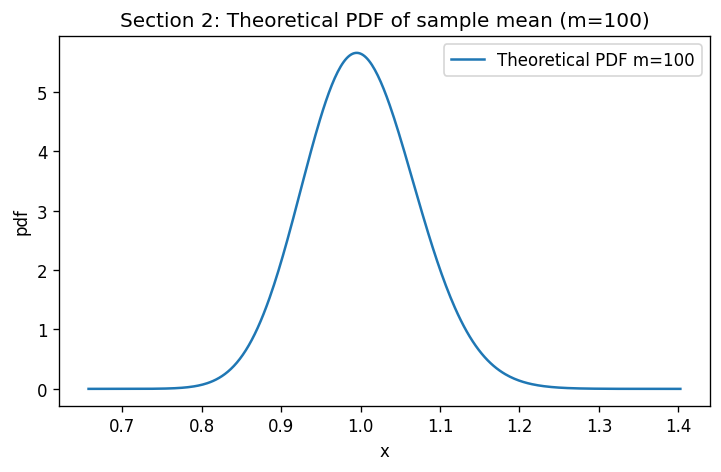

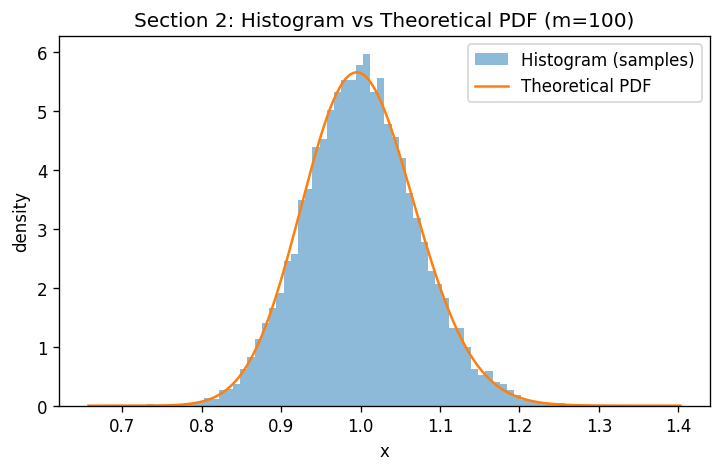

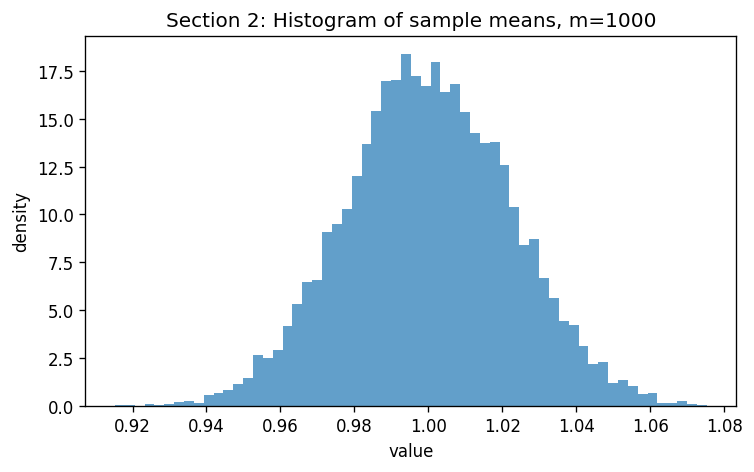

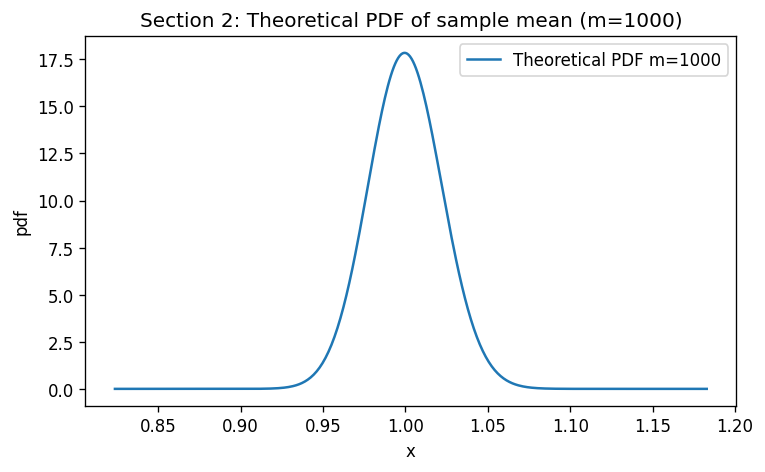

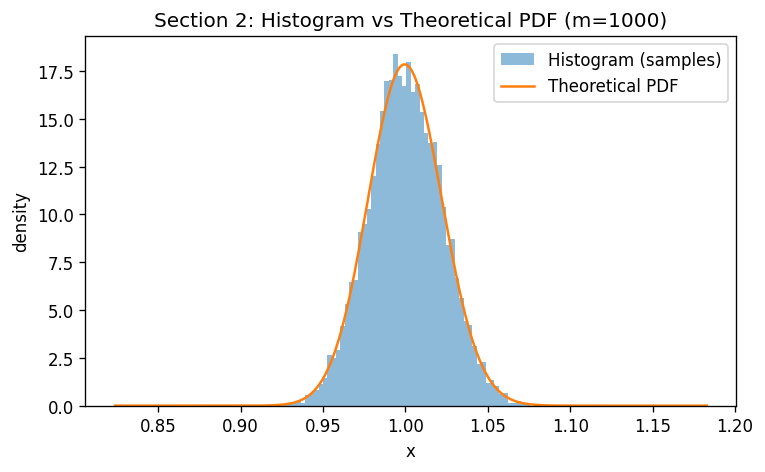

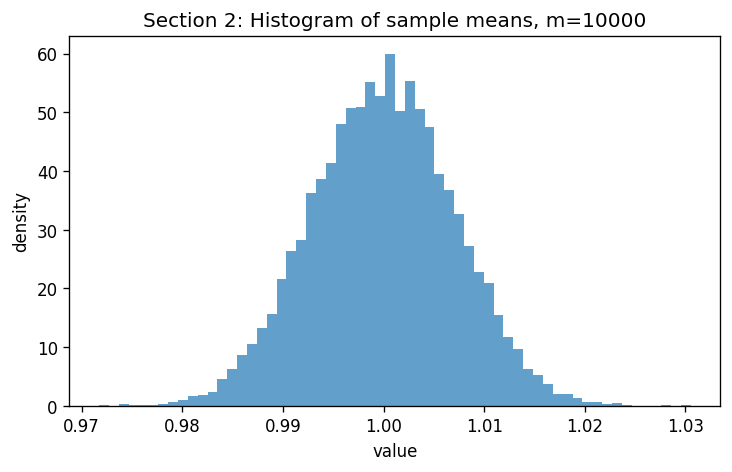

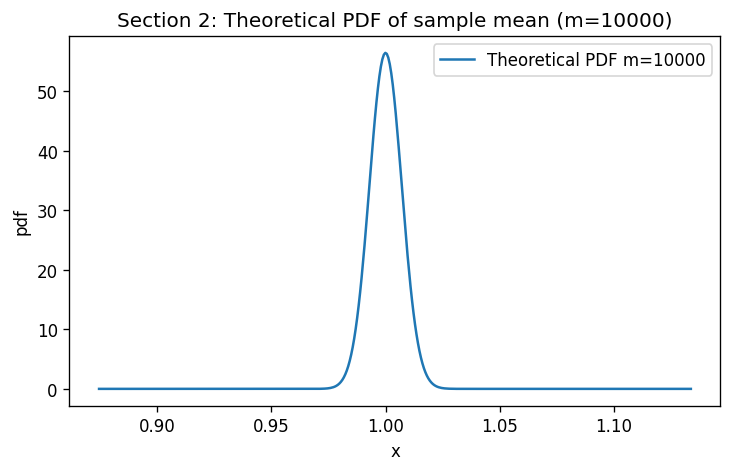

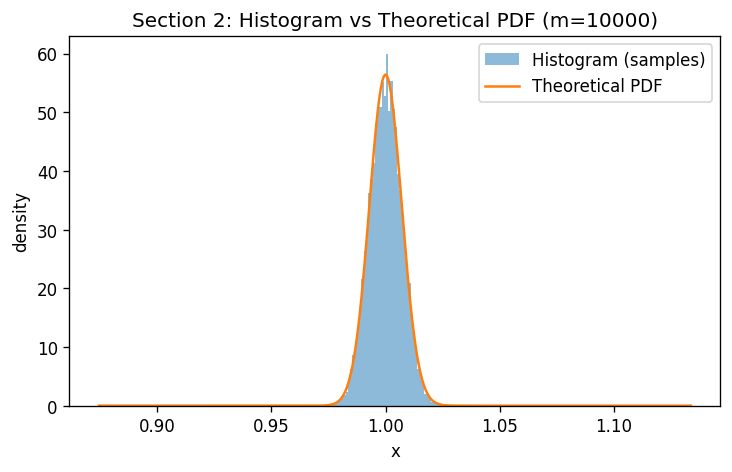

In [17]:

alpha, lam = 2.0, 2.0
scale = 1.0 / lam  # 0.5

def sample_mean_samples(m, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    samples = stats.gamma.rvs(a=alpha, scale=scale, size=(n, m), random_state=rng)
    return samples.mean(axis=1)

class sample_mean_distribution:
    def __init__(self, m):
        self.m = m
        self.shape = alpha * m   # 2m
        self.scale = scale / m   # 0.5/m
        self.dist = stats.gamma(a=self.shape, scale=self.scale)
    def pdf(self, x):
        return self.dist.pdf(x)
    def rvs(self, size=1, random_state=None):
        return self.dist.rvs(size=size, random_state=random_state)

m_values = [10, 100, 1000, 10000]
sample_means = {}

for mval in m_values:
    sample_means[mval] = sample_mean_samples(m=mval, n=10000, rng=rng)

    plt.hist(sample_means[mval], bins=60, density=True, alpha=0.7)
    plt.title(f"Section 2: Histogram of sample means, m={mval}")
    plt.xlabel("value"); plt.ylabel("density")
    plt.show()

    dist_obj = sample_mean_distribution(mval)
    xs = np.linspace(max(1e-6, sample_means[mval].min()*0.9), sample_means[mval].max()*1.1, 400)
    pdf_vals = dist_obj.pdf(xs)

    plt.plot(xs, pdf_vals, label=f"Theoretical PDF m={mval}")
    plt.title(f"Section 2: Theoretical PDF of sample mean (m={mval})")
    plt.xlabel("x"); plt.ylabel("pdf"); plt.legend(); plt.show()

    plt.hist(sample_means[mval], bins=60, density=True, alpha=0.5, label="Histogram (samples)")
    plt.plot(xs, pdf_vals, label="Theoretical PDF")
    plt.title(f"Section 2: Histogram vs Theoretical PDF (m={mval})")
    plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.show()



## Section 3 — Maximum Likelihood Estimation


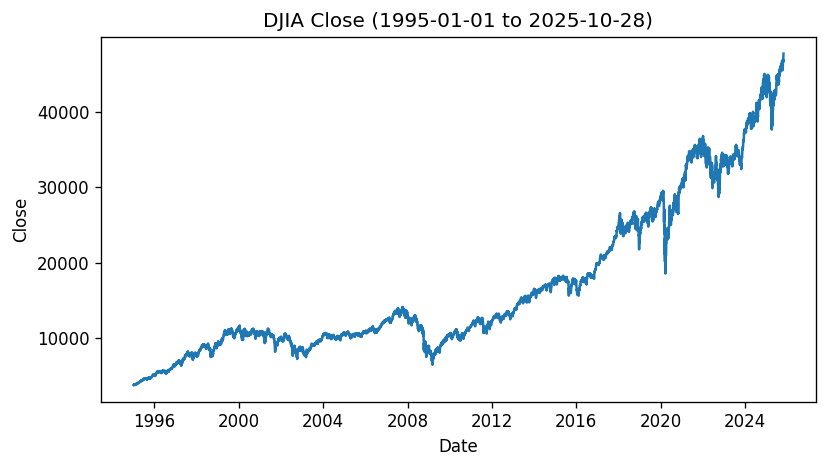

Mean: -0.026033, Var: 1.294459, Skew: 0.628024, Kurtosis: 16.165161
MLE parameters (Student-t): 2.855617705387653 -0.06477031517612333 0.6790262871435487


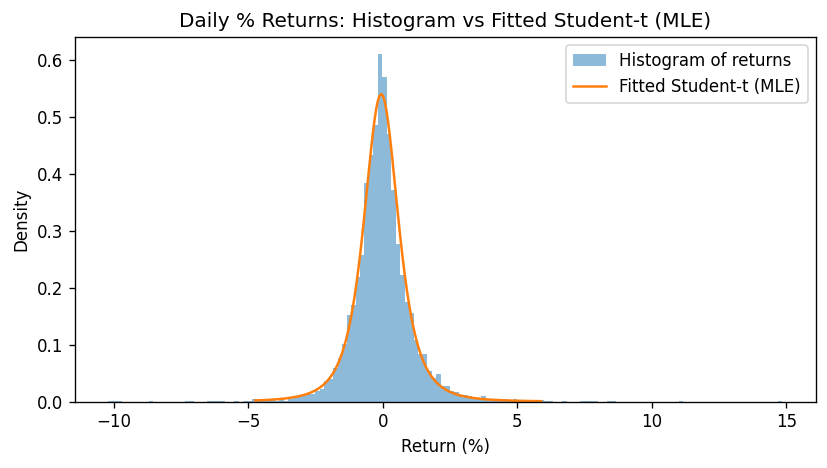

scipy.stats.t.fit parameters: 2.855600443157875 -0.06476645970336958 0.6790247164646497


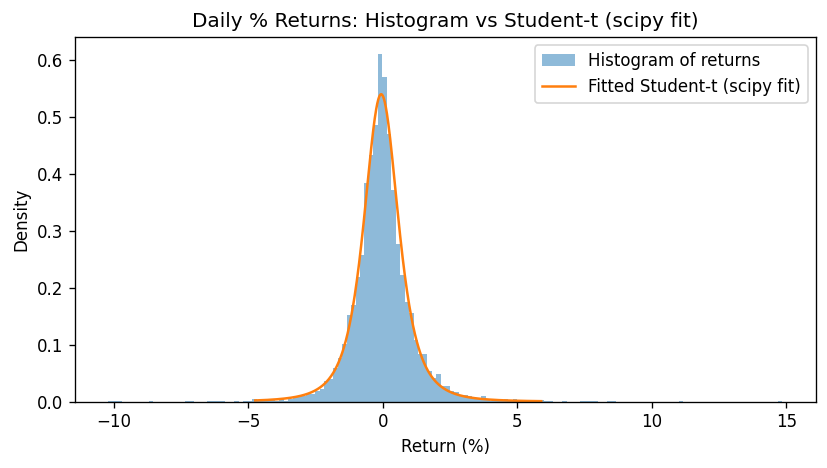

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import pandas_datareader.data as web

data = web.DataReader('^DJI', 'stooq', start='1995-01-01', end='2025-10-28')
data = data.reset_index()
dates = data["Date"]
dow = data["Close"].to_numpy()

plt.plot(dates, dow)
plt.title("DJIA Close (1995-01-01 to 2025-10-28)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.tight_layout()
plt.show()

returns = 100.0 * (dow[1:] / dow[:-1] - 1.0)

mean_r = np.mean(returns)
var_r = np.var(returns, ddof=1)
skew_r = stats.skew(returns, bias=False)
kurt_r = stats.kurtosis(returns, fisher=False, bias=False)

print(f"Mean: {mean_r:.6f}, Var: {var_r:.6f}, Skew: {skew_r:.6f}, Kurtosis: {kurt_r:.6f}")

def neg_loglike_t(params, x):
    df, loc, scale = params
    if df <= 2 or scale <= 0:
        return np.inf
    return -np.sum(stats.t.logpdf(x, df=df, loc=loc, scale=scale))

x0 = np.array([6.0, np.mean(returns), np.std(returns, ddof=1)])
bounds = [(2.01, 200.0), (None, None), (1e-6, None)]

res = optimize.minimize(lambda p: neg_loglike_t(p, returns),
                        x0, bounds=bounds, method="L-BFGS-B")
df_mle, loc_mle, scale_mle = res.x
print("MLE parameters (Student-t):", df_mle, loc_mle, scale_mle)


plt.hist(returns, bins=150, density=True, alpha=0.5, label="Histogram of returns")
xs = np.linspace(np.percentile(returns, 0.2), np.percentile(returns, 99.8), 800)
pdf_fit = stats.t.pdf(xs, df=df_mle, loc=loc_mle, scale=scale_mle)
plt.plot(xs, pdf_fit, label="Fitted Student-t (MLE)")
plt.title("Daily % Returns: Histogram vs Fitted Student-t (MLE)")
plt.xlabel("Return (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


df_fit, loc_fit, scale_fit = stats.t.fit(returns)
print("scipy.stats.t.fit parameters:", df_fit, loc_fit, scale_fit)

plt.hist(returns, bins=150, density=True, alpha=0.5, label="Histogram of returns")
pdf_fit2 = stats.t.pdf(xs, df=df_fit, loc=loc_fit, scale=scale_fit)
plt.plot(xs, pdf_fit2, label="Fitted Student-t (scipy fit)")
plt.title("Daily % Returns: Histogram vs Student-t (scipy fit)")
plt.xlabel("Return (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()



## 2.Additional Theory Exercises

### 1. Normal sample means


### 2. Mean vs median for \([3,4,2,5]\) + \(x > 5\)
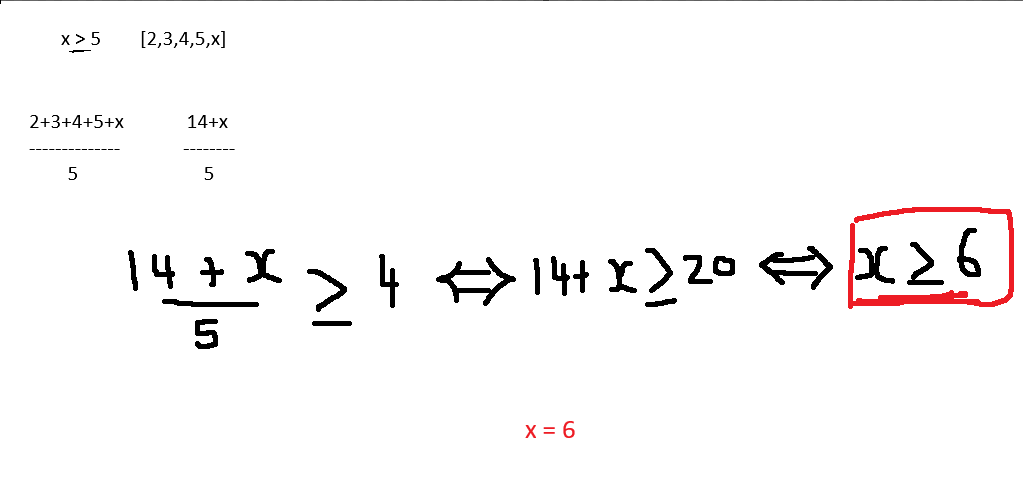

### 3. Binominal Distribution
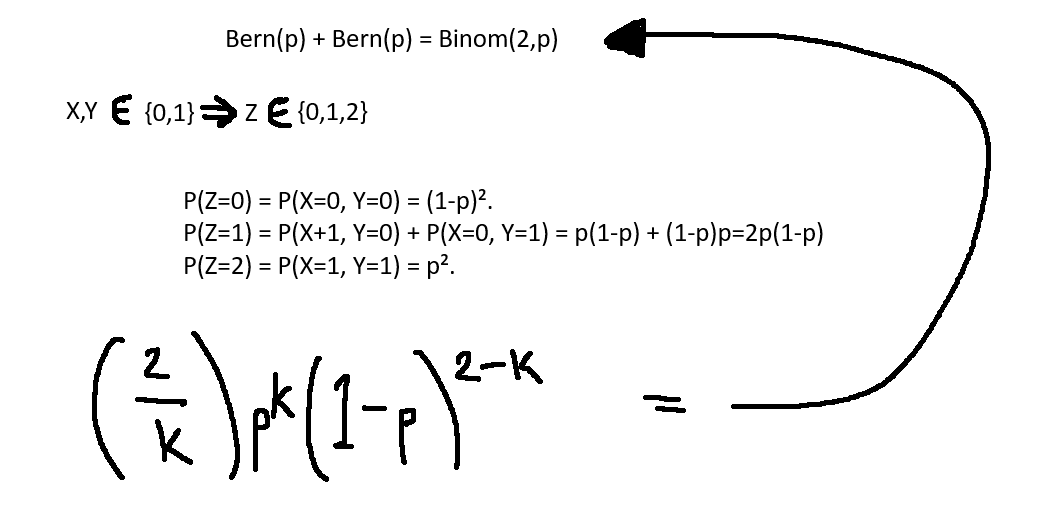

### 4. PMF of

